# Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import pylidc as pl
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
from tabulate import tabulate
from contextlib import redirect_stdout

In [2]:
# ============================================
# LOAD ALL SCANS
# ============================================
scans = pl.query(pl.Scan).all()
print(f"Total scan objects loaded: {len(scans)}")

Total scan objects loaded: 1018


# Total Studies and Unique Patient from LIDC-IDRI Dataset

In [3]:
# ============================================
# EXTRACT PATIENT IDS
# ============================================

patient_ids = [scan.patient_id for scan in scans]

# Count total studies
total_studies = len(patient_ids)

# Get unique patient ids
unique_patients = sorted(set(patient_ids))
total_unique_patients = len(unique_patients)

# Count occurrences of each patient id
scan_count_per_patient = Counter(patient_ids)

# Find duplicated patient ids automatically
duplicate_patients = {
    pid: count
    for pid, count in scan_count_per_patient.items()
    if count > 1
}

# ============================================
# CREATE SUMMARY DATAFRAME
# ============================================

summary_df = pd.DataFrame({
    "Metric": [
        "Total Studies",
        "Total Unique Patients"
    ],
    "Value": [
        total_studies,
        total_unique_patients
    ]
})

display(summary_df)

,Metric,Value
0,Total Studies,1018
1,Total Unique Patients,1010


# Check Patient with Multiple Studies

In [4]:
# Automatically get duplicated patient ids
duplicate_ids = list(duplicate_patients.keys())

for pid in duplicate_ids:
    scans_pid = pl.query(pl.Scan).filter(
        pl.Scan.patient_id == pid
    ).all()

    print("=" * 60)
    print(f"Patient ID: {pid}")
    print(f"Number of scans: {len(scans_pid)}")

    for i, scan in enumerate(scans_pid):

        print(f"\nScan {i+1}")
        print(f"Study UID      : {scan.study_instance_uid}")
        print(f"Series UID     : {scan.series_instance_uid}")
        print(f"Slice Thickness: {scan.slice_thickness}")

Patient ID: LIDC-IDRI-0132
Number of scans: 2

Scan 1
Study UID      : 1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102832118810712329678
Series UID     : 1.3.6.1.4.1.14519.5.2.1.6279.6001.151647338241909635299641922057
Slice Thickness: 3.0

Scan 2
Study UID      : 1.3.6.1.4.1.14519.5.2.1.6279.6001.314138616411061948052843767346
Series UID     : 1.3.6.1.4.1.14519.5.2.1.6279.6001.254176853278710432756285662989
Slice Thickness: 3.0
Patient ID: LIDC-IDRI-0151
Number of scans: 2

Scan 1
Study UID      : 1.3.6.1.4.1.14519.5.2.1.6279.6001.222444895275634974977432374937
Series UID     : 1.3.6.1.4.1.14519.5.2.1.6279.6001.453946099750629491201946672998
Slice Thickness: 3.0

Scan 2
Study UID      : 1.3.6.1.4.1.14519.5.2.1.6279.6001.780121538270617222115253441513
Series UID     : 1.3.6.1.4.1.14519.5.2.1.6279.6001.768856069922657732839929586657
Slice Thickness: 3.0
Patient ID: LIDC-IDRI-0315
Number of scans: 2

Scan 1
Study UID      : 1.3.6.1.4.1.14519.5.2.1.6279.6001.190722769298607626547238572819


# LIDC-IDRI Studies Metadata Exploration

## Collect Matadata From All LIDC-IDRI Studies

In [ ]:
study_metadata_list = []
failed_studies = []

for scan in tqdm(scans, desc="Processing studies"):
    try:
        # Suppress PyLIDC loading message
        with open(os.devnull, "w") as devnull:
            with redirect_stdout(devnull):
                dicom_images = scan.load_all_dicom_images()

        middle_idx = len(dicom_images) // 2
        middle_dicom = dicom_images[middle_idx]

        z_positions = sorted(
            float(dcm.ImagePositionPatient[2])
            for dcm in dicom_images
        )

        slice_spacing_mm = np.mean(np.diff(z_positions))

        study_metadata = {
            "study_instance_uid": scan.study_instance_uid,
            "num_slices": len(dicom_images),
            "slice_thickness_mm": float(middle_dicom.SliceThickness),
            "slice_spacing_mm": float(slice_spacing_mm),
            "pixel_spacing_x_mm": float(middle_dicom.PixelSpacing[0]),
            "pixel_spacing_y_mm": float(middle_dicom.PixelSpacing[1]),
        }

        study_metadata_list.append(study_metadata)

    except Exception as e:
        print(
            f"\n[ERROR] Failed to process study "
            f"{scan.study_instance_uid}: {e}"
        )

        failed_studies.append({
            "study_instance_uid": scan.study_instance_uid,
            "error": str(e)
        })

# Convert to DataFrame
study_metadata_df = pd.DataFrame(study_metadata_list)

# Save metadata
output_file = "../dataset/lidc_idri_metadata/lidc_idri_study_metadata.csv"
study_metadata_df.to_csv(output_file, index=False)

print(f"\nMetadata saved successfully to '{output_file}'")
print(f"Processed studies : {len(study_metadata_df)}")
print(f"Failed studies    : {len(failed_studies)}")

Processing studies: 100%|██████████| 1018/1018 [1:39:56<00:00,  5.89s/it]


Metadata saved successfully to '../dataset/lidc_idri_metadata/lidc_idri_study_metadata.csv'
Processed studies : 1018
Failed studies    : 0


In [5]:
study_metadata_df = pd.read_csv("../dataset/lidc_idri_metadata/lidc_idri_study_metadata.csv", index_col=False)
study_metadata_df.describe()


,num_slices,slice_thickness_mm,slice_spacing_mm,pixel_spacing_x_mm,pixel_spacing_y_mm
count,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000
mean,239.631631,1.918713,1.739906,0.687689,0.687689
std,133.457158,0.728916,0.836544,0.084851,0.084851
min,65.000000,0.600000,0.450000,0.460938,0.460938
25%,133.000000,1.250000,1.000000,0.625000,0.625000
50%,203.500000,2.000000,1.375000,0.698609,0.698609
75%,289.750000,2.500000,2.500000,0.742188,0.742188
max,764.000000,5.000000,5.000000,0.976562,0.976562


## Distribution of Number of Slices per Study

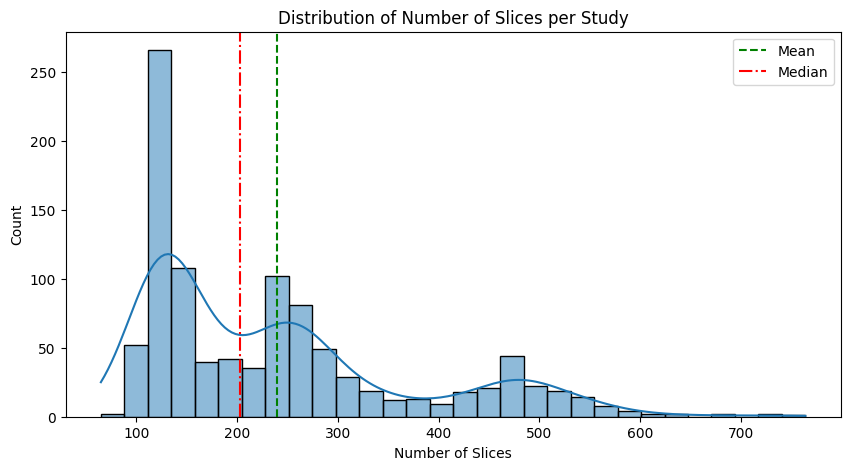

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(
    study_metadata_df["num_slices"],
    bins=30,
    kde=True
)

plt.axvline(
    study_metadata_df["num_slices"].mean(),
    linestyle="--",
    label="Mean",
    color="g"
)

plt.axvline(
    study_metadata_df["num_slices"].median(),
    linestyle="-.",
    label="Median",
    color="r"
)

plt.title("Distribution of Number of Slices per Study")
plt.xlabel("Number of Slices")
plt.ylabel("Count")
plt.legend()

plt.show()

## Ditribution of Slice Thickness

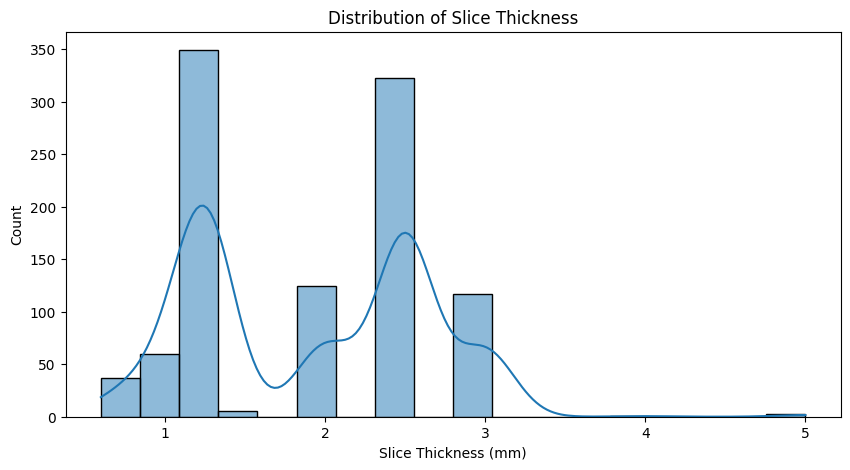

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(
    study_metadata_df["slice_thickness_mm"],
    bins="auto",
    kde=True
)

plt.title("Distribution of Slice Thickness")
plt.xlabel("Slice Thickness (mm)")
plt.ylabel("Count")

plt.show()

## Ditribution of Slice Spacing

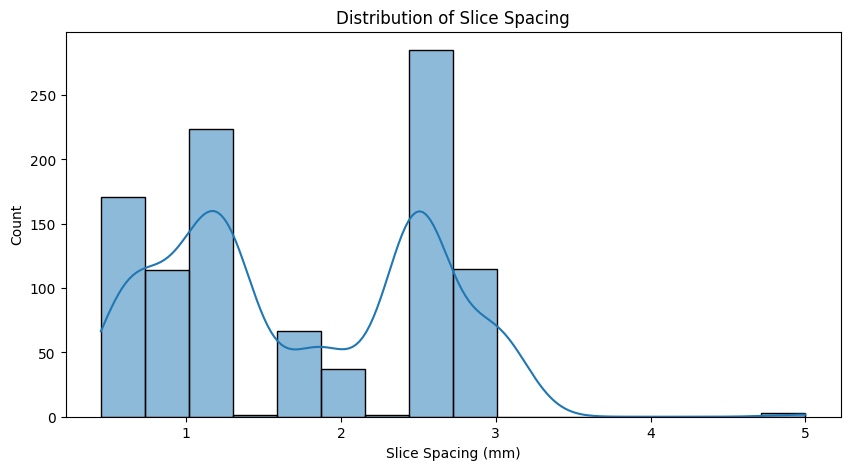

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(
    study_metadata_df["slice_spacing_mm"],
    bins="auto",
    kde=True
)

plt.title("Distribution of Slice Spacing")
plt.xlabel("Slice Spacing (mm)")
plt.ylabel("Count")

plt.show()

## Boxplot Visualization

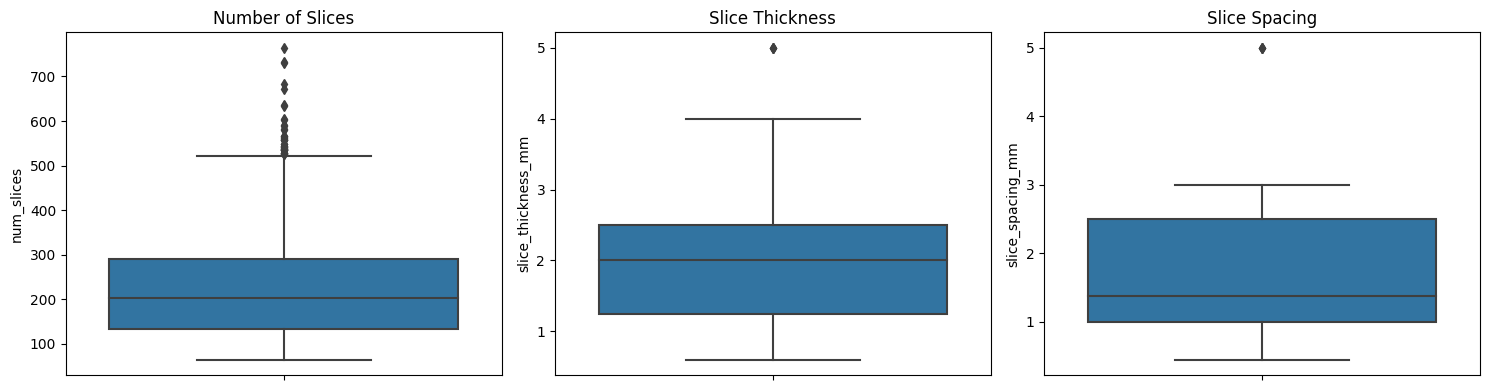

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=study_metadata_df["num_slices"], ax=axes[0])
axes[0].set_title("Number of Slices")

sns.boxplot(y=study_metadata_df["slice_thickness_mm"], ax=axes[1])
axes[1].set_title("Slice Thickness")

sns.boxplot(y=study_metadata_df["slice_spacing_mm"], ax=axes[2])
axes[2].set_title("Slice Spacing")

plt.tight_layout()
plt.show()

* The LIDC-IDRI dataset contains **1018 total studies**, which represent all `Scan` objects returned by PyLIDC.
* The dataset contains **1010 unique patients**, identified using unique `patient_id` values.
* There are **8 patients** that have more than one CT scan/study in the dataset:
  * `LIDC-IDRI-0132`
  * `LIDC-IDRI-0151`
  * `LIDC-IDRI-0315`
  * `LIDC-IDRI-0332`
  * `LIDC-IDRI-0355`
  * `LIDC-IDRI-0365`
  * `LIDC-IDRI-0442`
  * `LIDC-IDRI-0484`
* These duplicated patient IDs are not dataset errors; they indicate that the same patient has multiple CT scan studies.
* A **Study Instance UID** uniquely identifies one DICOM study or examination performed on a patient.
* A **Series Instance UID** uniquely identifies one image series within a study.
* The dataset contains a total of **243,945 CT slices** across all studies.
* The minimum number of slices in one study is **65 slices**, while the maximum reaches **764 slices**, showing a large variation in CT volume depth.
* The average number of slices per study is approximately **239.63 slices**, with a median of **203.50 slices**.
* The standard deviation is relatively high (**133.39 slices**), indicating substantial variability in scan length between studies.
* Based on the histogram distribution, most studies are concentrated around **100–300 slices**, with several studies containing significantly larger numbers of slices.
* The slice distribution is positively skewed (right-skewed), meaning a small number of studies contain very large CT volumes compared to the majority of the dataset.


# Clustering

In [20]:
# ============================================
# SET CSV PATH
# ============================================

csv_path = "../dataset/lidc_idri_metadata/lidc_nodule_clusters.csv"

In [21]:
# ============================================
# CHECK WHETHER CLUSTER CSV ALREADY EXISTS
# ============================================

if os.path.exists(csv_path):

    print("Cluster CSV already exists.")
    print("Loading precomputed cluster metadata...\n")

    # Load existing CSV
    cluster_df = pd.read_csv(csv_path)

else:

    print("Cluster CSV not found.")
    print("Running annotation clustering...\n")

    # ============================================
    # LOAD ALL SCANS
    # ============================================

    scans = pl.query(pl.Scan).all()

    # ============================================
    # BUILD CLUSTER METADATA
    # ============================================

    cluster_rows = []

    # tqdm progress bar
    for scan_idx, scan in enumerate(
        tqdm(scans, desc="Clustering scans")
    ):

        # Cluster annotations for current scan
        clusters = scan.cluster_annotations()

        for nodule_idx, cluster in enumerate(clusters):

            # Annotation IDs
            annotation_ids = [ann.id for ann in cluster]

            # Malignancy features
            malignancies = [ann.malignancy for ann in cluster]

            # Geometric features
            diameters = [ann.diameter for ann in cluster]
            volumes = [ann.volume for ann in cluster]
            surface_areas = [ann.surface_area for ann in cluster]

            # Semantic features
            subtleties = [ann.subtlety for ann in cluster]
            textures = [ann.texture for ann in cluster]
            spiculations = [ann.spiculation for ann in cluster]
            lobulations = [ann.lobulation for ann in cluster]

            # Store cluster information
            cluster_rows.append({

                # Scan information
                "patient_id": scan.patient_id,
                "study_instance_uid": scan.study_instance_uid,
                "series_instance_uid": scan.series_instance_uid,

                # Scan metadata
                "slice_thickness": scan.slice_thickness,
                "pixel_spacing": scan.pixel_spacing,
                "num_slices": len(scan.slice_zvals),
                "contrast_used": scan.contrast_used,
                "is_from_initial": scan.is_from_initial,

                # Nodule information
                "nodule_idx": nodule_idx,
                "num_annotations": len(cluster),
                "annotation_ids": annotation_ids,

                # Malignancy
                "malignancy_mean": np.mean(malignancies),
                "malignancy_std": np.std(malignancies),

                # Geometric features
                "diameter_mean": np.mean(diameters),
                "volume_mean": np.mean(volumes),
                "surface_area_mean": np.mean(surface_areas),

                # Semantic features
                "subtlety_mean": np.mean(subtleties),
                "texture_mean": np.mean(textures),
                "spiculation_mean": np.mean(spiculations),
                "lobulation_mean": np.mean(lobulations)
            })

    # ============================================
    # CONVERT TO DATAFRAME
    # ============================================

    cluster_df = pd.DataFrame(cluster_rows)

    # ============================================
    # SAVE CSV
    # ============================================

    cluster_df.to_csv(
        csv_path,
        index=False
    )

    print(f"\nCluster metadata saved to: {csv_path}")

Cluster CSV already exists.
Loading precomputed cluster metadata...



In [22]:
# ============================================
# DISPLAY RESULT
# ============================================

cluster_df = pd.read_csv("../dataset/lidc_idri_metadata/lidc_nodule_clusters.csv")
print(f"\nTotal nodules: {len(cluster_df)}")

cluster_df.head()


Total nodules: 2651


,patient_id,study_instance_uid,series_instance_uid,slice_thickness,pixel_spacing,num_slices,contrast_used,is_from_initial,nodule_idx,num_annotations,annotation_ids,malignancy_mean,malignancy_std,diameter_mean,volume_mean,surface_area_mean,subtlety_mean,texture_mean,spiculation_mean,lobulation_mean
0,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,3.0,0.650,87,True,False,0,4,"[2, 6, 10, 13]",3.75,0.829156,23.945243,2516.304375,1193.424473,4.50,4.75,2.25,2.25
1,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,3.0,0.650,87,True,False,1,4,"[1, 5, 9, 12]",3.75,0.829156,20.694395,2193.250312,1018.748994,4.75,4.50,2.25,3.00
2,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,3.0,0.650,87,True,False,2,1,[8],1.00,0.000000,5.076662,62.107500,66.910605,4.00,5.00,1.00,1.00
3,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,3.0,0.650,87,True,False,3,4,"[3, 4, 7, 11]",4.25,0.829156,27.694350,4870.685625,1870.264307,5.00,4.75,2.75,3.25
4,LIDC-IDRI-0069,1.3.6.1.4.1.14519.5.2.1.6279.6001.303241414168...,1.3.6.1.4.1.14519.5.2.1.6279.6001.131939324905...,2.0,0.741,136,True,False,0,4,"[16, 18, 20, 22]",3.25,1.089725,12.648800,585.183076,401.426716,2.50,4.75,4.00,4.00


In [23]:
# ============================================
# DESCRIPTIVE STATISTICS OF CLUSTER METADATA
# ============================================
cluster_df.describe()

,slice_thickness,pixel_spacing,num_slices,nodule_idx,num_annotations,malignancy_mean,malignancy_std,diameter_mean,volume_mean,surface_area_mean,subtlety_mean,texture_mean,spiculation_mean,lobulation_mean
count,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000
mean,1.883252,0.687771,246.129762,2.158431,2.587326,2.695346,0.403416,10.161367,630.330489,375.657790,3.661871,4.315742,1.534609,1.627295
std,0.747306,0.083143,131.252615,2.779538,1.249986,0.919823,0.422553,6.733856,1779.426900,695.361970,1.076429,1.153934,0.841819,0.835827
min,0.600000,0.460938,65.000000,0.000000,1.000000,1.000000,0.000000,2.585936,8.544922,13.761003,1.000000,1.000000,1.000000,1.000000
25%,1.250000,0.632812,133.000000,0.000000,1.000000,2.000000,0.000000,6.128319,63.627390,84.093594,3.000000,4.000000,1.000000,1.000000
50%,2.000000,0.698000,235.000000,1.000000,3.000000,2.750000,0.433013,7.818802,122.416228,137.672610,4.000000,5.000000,1.000000,1.250000
75%,2.500000,0.742188,300.000000,3.000000,4.000000,3.000000,0.707107,11.144932,323.061775,299.769071,4.500000,5.000000,1.750000,2.000000
max,5.000000,0.976562,764.000000,22.000000,8.000000,5.000000,2.000000,49.944618,31112.197113,9026.567042,5.000000,5.000000,5.000000,5.000000


## Distribution of Num Annotation per Cluster

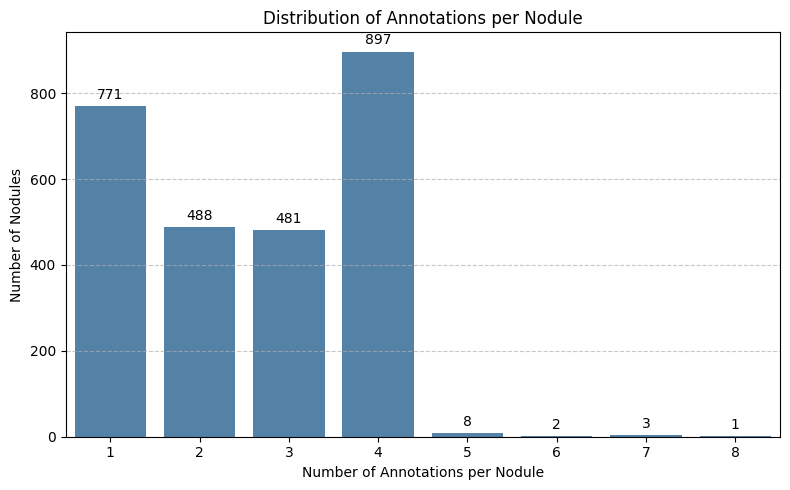

In [24]:
# ============================================
# PLOT DISTRIBUTION OF NUM ANNOTATIONS PER NODULE
# ============================================

# Count frequency of each annotation count
annotation_counts = (
    cluster_df["num_annotations"]
    .value_counts()
    .sort_index()
    .reset_index()
)

annotation_counts.columns = [
    "num_annotations",
    "num_nodules"
]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=annotation_counts,
    x="num_annotations",
    y="num_nodules",
    color="steelblue"
)

# Add value labels above bars
for container in ax.containers:

    ax.bar_label(
        container,
        fmt='%d',
        padding=3
    )

plt.xlabel("Number of Annotations per Nodule")
plt.ylabel("Number of Nodules")
plt.title("Distribution of Annotations per Nodule")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

## Distribution of Diameter Nodules

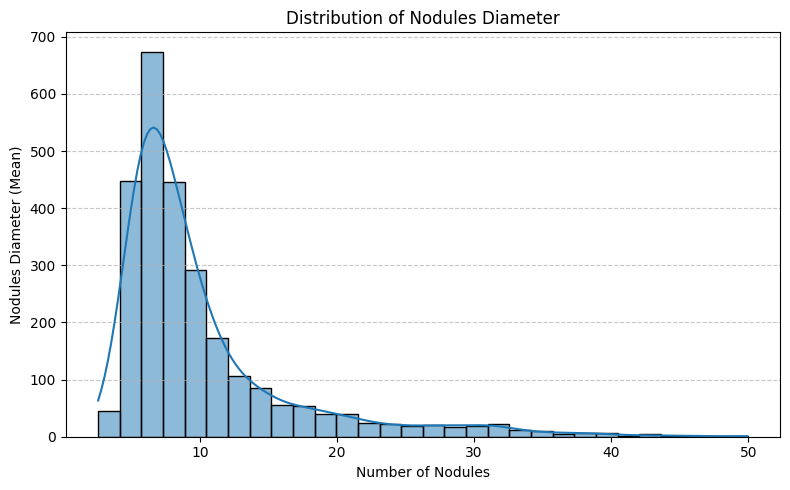

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    cluster_df["diameter_mean"],
    bins=30,
    kde=True
)

plt.xlabel("Number of Nodules")
plt.ylabel("Nodules Diameter (Mean)")
plt.title("Distribution of Nodules Diameter")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

## Diameter VS Number of Annotations

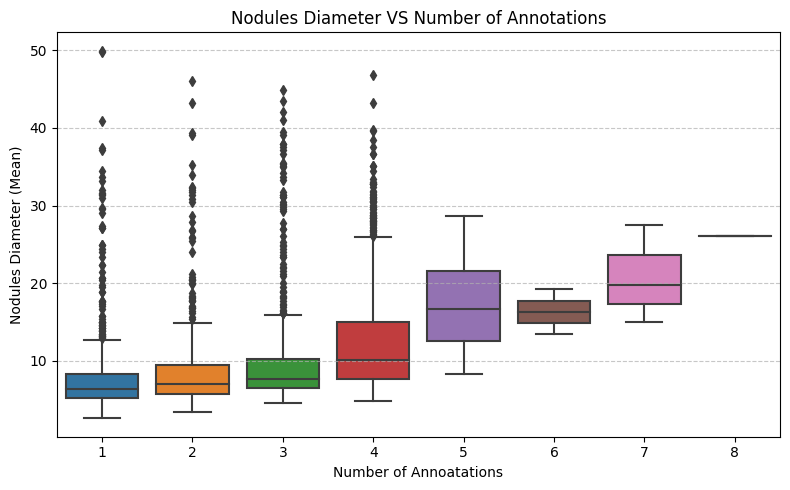

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="num_annotations",
    y="diameter_mean",
    data=cluster_df
)

plt.xlabel("Number of Annoatations")
plt.ylabel("Nodules Diameter (Mean)")
plt.title("Nodules Diameter VS Number of Annotations")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

## Malignancy

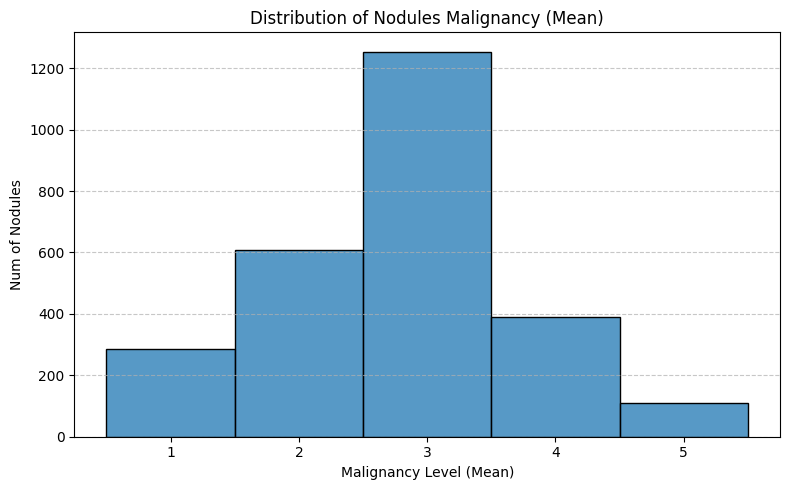

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    cluster_df["malignancy_mean"],
    bins=np.arange(1, 7)-0.5
)

plt.xlabel("Malignancy Level (Mean)")
plt.ylabel("Num of Nodules")
plt.title("Distribution of Nodules Malignancy (Mean)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

## Diameter VS Malignancy

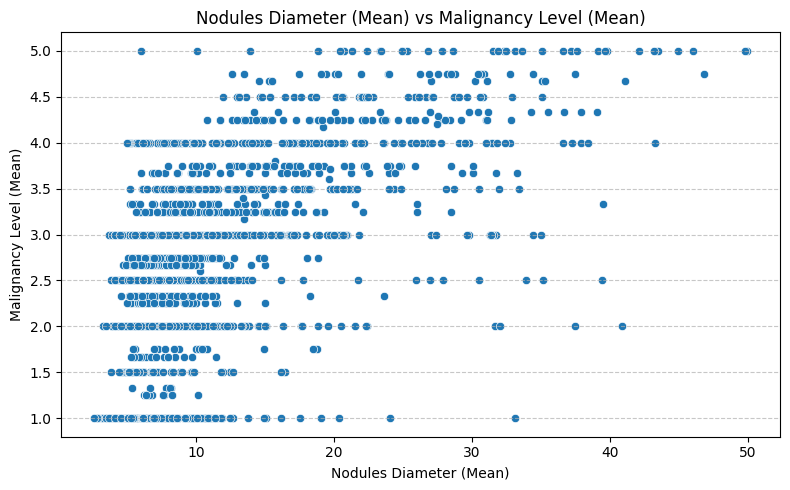

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=cluster_df,
    x="diameter_mean",
    y="malignancy_mean"
)

plt.xlabel("Nodules Diameter (Mean)")
plt.ylabel("Malignancy Level (Mean)")
plt.title("Nodules Diameter (Mean) vs Malignancy Level (Mean)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

<AxesSubplot:>

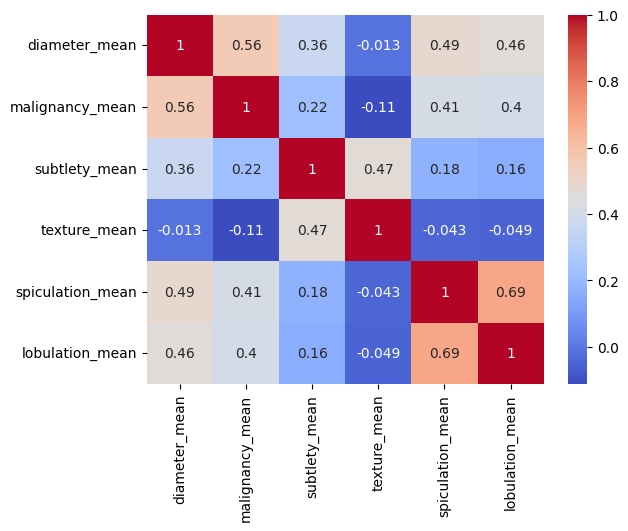

In [39]:
features = [
    "diameter_mean",
    "malignancy_mean",
    "subtlety_mean",
    "texture_mean",
    "spiculation_mean",
    "lobulation_mean"
]

corr = cluster_df[features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

# Sampling

In [53]:
print(f"Initial clusters: {len(cluster_df)}")

Initial clusters: 2651


In [54]:
diameter_filtered_df = cluster_df[
    cluster_df["diameter_mean"].between(3, 30)
].copy()

print(f"After diameter filtering: {len(diameter_filtered_df)}")

After diameter filtering: 2565


In [55]:
annotator_filtered_df = diameter_filtered_df[
    diameter_filtered_df["num_annotations"] >= 3
].copy()

print(f"After radiologist filtering: {len(annotator_filtered_df)}")

After radiologist filtering: 1335


In [61]:
selected_df = annotator_filtered_df.copy()

selected_df["class_label"] = np.where(
    selected_df["malignancy_mean"] <= 2.5,
    "benign",
    np.where(
        selected_df["malignancy_mean"] >= 3.5,
        "malignant",
        "ambiguous"
    )
)

selected_df = selected_df[
    selected_df["class_label"] != "ambiguous"
].copy()

selected_df.to_csv("../dataset/lidc_idri_metadata/selected_nodule.csv", index=False)
print(f"Final selected nodules: {len(selected_df)}")

Final selected nodules: 756


In [57]:
selected_df["class_label"].value_counts()

benign       422
malignant    334
Name: class_label, dtype: int64

In [58]:
selection_summary = {
    "Initial clusters": len(cluster_df),
    "Diameter 3-30 mm": len(diameter_filtered_df),
    "≥3 annotations": len(annotator_filtered_df),
    "Final selected": len(selected_df)
}

print(pd.Series(selection_summary))

Initial clusters    2651
Diameter 3-30 mm    2565
≥3 annotations      1335
Final selected       756
dtype: int64
